## Assignment 1: Wrangling and EDA
Katherine DeForrest

In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Q1.

In [84]:
#1.
df = pd.read_csv("/workspace/scratchpad/data/airbnb_NYC.csv", encoding="latin1")
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [85]:
df['Price'] = pd.to_numeric(df['Price'].str.replace(',', ''), errors='coerce')
print("Missing values:", df['Price'].isna().sum())

Missing values: 0


To clean the Price variable, I replaced all of the commas from when the price gets to the thousands so the data is easier to work with, and then converted the column to a numeric data type instead of an object. After this, I ended up with 0 missing values. 

In [86]:
#2. 

df = pd.read_csv("//workspace/scratchpad/data/mn_police_use_of_force.csv")
df.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [87]:
print("Proportion of missing values:", df['subject_injury'].isna().mean())
df.head()
pd.crosstab(df['subject_injury'], df['force_type'], dropna=False)

Proportion of missing values: 0.7619342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
NaN,2,7051,1421,0,27,74,87,0,170,31,985


The data are missing more often when the police use force at all. There are especially more cases of missing data for when bodily force, a chemical irritant, and a taser are used. However, all of the data are missing for when a less lethal or maximal restraint technique are used. 

In [88]:
df['subject_injury'] = df['subject_injury'].fillna('Missing')
df.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,Missing,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,Missing,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,Missing,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,Missing,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,Missing,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [89]:
#3. 

df = pd.read_csv("/workspace/scratchpad/data/metabric.csv")
df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


In [90]:
df['Overall Survival Status'] = df['Overall Survival Status'].replace({'0:LIVING':'1', '1:DECEASED':'0'})
df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,1,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,0,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,1,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,0,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,0,YES,5.230071,31.0,4.0


In [91]:
#4. 

df = pd.read_csv("/workspace/scratchpad/data/airbnb_NYC.csv", encoding="latin1")
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [92]:
print("Number of missing values:",df['Review Scores Rating'].isna().sum())
median1 = df['Review Scores Rating'].median()
df['Review Scores Rating Imputed'] = df['Review Scores Rating'].fillna(median1)
df.head()


Number of missing values: 8323


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Review Scores Rating Imputed
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN,94.0
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN,94.0
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN,94.0
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN,94.0
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,96.0


This may negatively impact my results because when analyzing the data, calculations may be skewed because there are more values of the median than there actually are. Additionally, the variability in the data is reduced when there are a larger amount of values of the median that are added to the data. It can also hide information about the data that are missing by adding the median into these values, therefore concealing what they can show about the data. 

Q2. 

In [93]:
pip install xlrd

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [94]:
#1. 
df = pd.read_excel("/workspace/GSAF5.xls", engine='xlrd')
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Using read_excel works instead of using read_csv as the shark attack file is not a csv file. 

In [95]:
#2. 
df = df.dropna(axis=1, how='all') #or thresh=len(df)*.90 if want more than 90% of data to be in column to keep it- there were no columns that were completely empty of data
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


3. An observation is an instance of a shark attack. It gives information about where, when, and the type of shark attack that occured. It affects my choices in cleaning and analyzing the data because each data point is a specific instance rather than data for a location or time period. For cleaning the data, if one observation is missing information, it should be dropped to not throw off the data set. Duplicates may also have to be removed. The analysis depends on the fact that each data point is complete and accurate and represents one observation. 

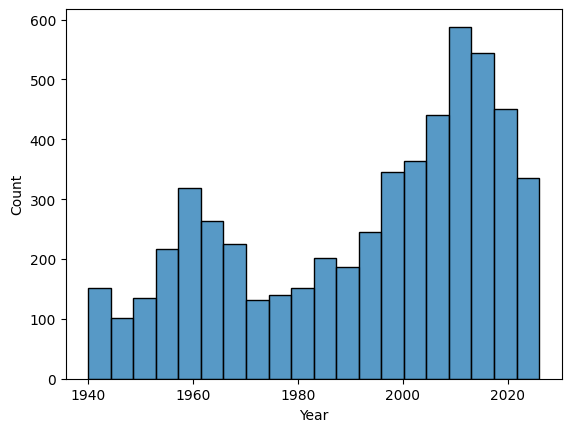

In [96]:
#4. 

df['Year'] = df['Year'].astype('Int64')
df2 = df[df['Year'] >= 1940]
sns.histplot(data=df2, x='Year', bins=20)
plt.show()

Attacks are overall increasing over time. 

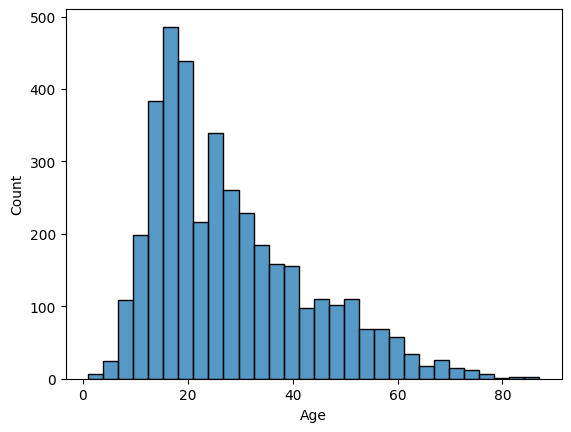

In [97]:
#5. 
df['Age'].dtype
df['Age'] = pd.to_numeric(df['Age'], errors ='coerce')   
sns.histplot(data=df, x='Age', bins=30)
plt.show()


In [98]:
#6
df['Type'] = df['Type'].str.strip().str.capitalize()
df['Type'].value_counts()

Type
Unprovoked             5225
Provoked                644
Invalid                 552
Watercraft              355
Sea disaster            242
Questionable             26
Boat                      7
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64

In [99]:
df = df[df['Type'].isin(['Provoked', 'Unprovoked', 'Unknown'])]
df['Type'].value_counts(normalize=True)

Type
Unprovoked    0.890271
Provoked      0.109729
Name: proportion, dtype: float64

.89 of attacks are unprovoked. 

In [100]:
#7. 
df['Fatal Y/N'] = df['Fatal Y/N'].str.strip().str.upper()
df['Fatal Y/N'].value_counts()

Fatal Y/N
N          4492
Y          1289
UNKNOWN      60
F             3
M             2
NQ            1
Name: count, dtype: int64

In [101]:
df = df[df['Fatal Y/N'].isin(['Y', 'N', 'UNKNOWN'])]

In [102]:
pd.crosstab(df['Type'], df['Fatal Y/N'], normalize='index')

Fatal Y/N,N,UNKNOWN,Y
Type,,,
Provoked,0.962382,0.004702,0.032915
Unprovoked,0.745339,0.010955,0.243706


8. The attack is less likely to be fatal when it is provoked (Y=.033) than when it is unprovoked (Y=.24). 

Q3. 

1. This paper is about the tidy datasets. Specifically, it details the benefits of tidy datasets, as well as the tools that are used to develop and analyze tidy data.

2. The tidy data standard makes data cleaning easier as it provides a framework and reliable structure. It is meant to allow for "inital exploration and analysis of the data" with tools and data that are proven to work well together. 

3. The first sentence means that, at its core, the structure of tidy data is the same and there are fundamental similarities between tidy data sets, even though there may be some slighter variation. However, messy datasets do not have any guaranteed shared characteristics and will all vary drastically from each other. 

The second sentence means that, on the surface, we can identify what the variables and the observations are from a data set by looking at the structure and the content of the data. However, if you try to define what an observation or a variable is for all data, it is hard to come to a simple and clear solution. An observation can count as something different for each dataset, there can be multiple levels of observation, and variables can greatly vary based on the type of data used and if they should be combined or viewed separately, what the context of a dataset is, and the relationship between different groups of observations. 

4. Values- either numbers or strings and a collection of them forms a dataset. Each value belongs to both a variable an an observation. 

Variables- a variable has all of the values that measure an attribute. 

Observation- an observation has all of the values that are measured on a unit across all attributes. 

5. A tidy dataset is defined in Section 2.3 as a dataset where each variable is a column, each observation is a row, and each observational unit forms a table. 

6. The 5 most common problems with messy data sets are-
- Column headers as values, not variable names
- Multiple variables stored in one column
- Variables are stored in both rows and columns
- Multiple types of observational units are stored in the same table
- A single observational unit is stored in multiple tables

The data in Table 4 are messy because the variables are both the row and the column values. The column headers are also the values of income, not the variable names. 

Melting a dataset is when columns are turned into rows. Colvars are a list of columns that are already variables, and a new column is created that has the column headings for each observation and a column value that has the data from the columns that were preciously separate. The new molten dataset will have the previous colvar, a new variable column, and a value column with the original values from the table. 

7. Table 11 is messy because there is a column for each day of the month rather than a row for each observation of a day, as well as a column for the variables tmax and tmin. Table 12 (b. and not a. which still has two observations for each day) is tidy and "molten" because each row contains the measurements for a single day, with the two variables of tmin and tmax for each day and one variable in each column. 

Q4.

In [103]:
#1. 
df = pd.read_csv("/workspace/scratchpad/data/ForeignGifts_edu.csv")
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


<Axes: xlabel='Foreign Gift Amount', ylabel='Count'>

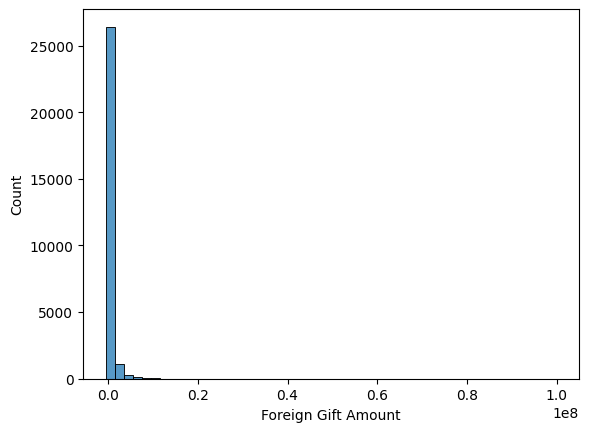

In [104]:
#2. 
sns.histplot(data=df, x='Foreign Gift Amount', bins=50)

Almsot all gifts are around the same amount and in the first bins. For the variable, the median is 94615. However, there are a few gifts that are far upper outliers, with a max of 99999999, that are a very high amount and make the histogram very right skewed. 

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64

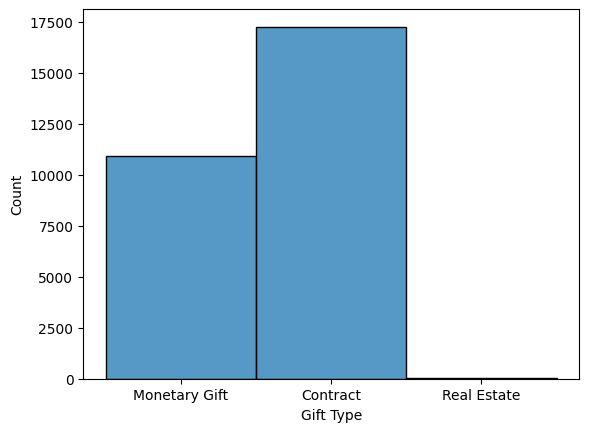

In [105]:
#3. 
sns.histplot(data=df, x='Gift Type')
df['Gift Type'].value_counts(normalize=True)

.61 of the gifts are contracts, .39 are montary gifts, and .0004 are real estate.

In [106]:
#4. 
df["Country of Giftor"].value_counts().head(15)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

In [107]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].value_counts().sort_index(level='Foreign Gift Amount', ascending=False).head(15)

Country of Giftor  Foreign Gift Amount
QATAR              99999999                6
AUSTRALIA          99999999                1
QATAR              77391377                1
BERMUDA            75000000               10
QATAR              74130684                4
                   69546001                1
THAILAND           67700000                1
QATAR              62181001                1
                   60071001                1
                   53878001                1
                   50521001                1
                   50300001                1
CANADA             48842186                1
AUSTRALIA          48355498                1
HONG KONG          47670277                1
Name: count, dtype: int64

In [108]:
#5. 
X = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
X.head(15)

Institution Name
Carnegie Mellon University                       1477922504
Cornell University                               1289937761
Harvard University                                954803610
Massachusetts Institute of Technology             859071692
Yale University                                   613441311
Texas A&M University                              521455050
Johns Hopkins University                          502409595
Northwestern University                           402316221
Georgetown University                             379950511
University of Chicago (The)                       364544338
University of Colorado Boulder                    360173159
Duke University                                   343699498
Brigham Young University                          323509863
Stanford University                               319561362
University of Texas MD Anderson Cancer Center     301527419
Name: Foreign Gift Amount, dtype: int64

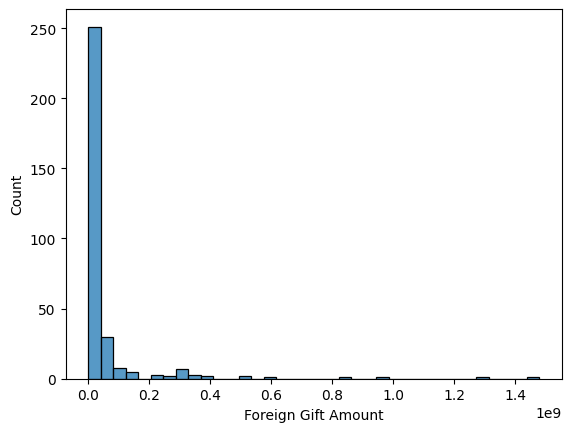

In [109]:
sns.histplot(X)
plt.show()

In [110]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

Qatar, England, and China provide the most money, in total. 

Q5. 

In [111]:
#1
df = pd.read_csv("/workspace/scratchpad/data/college_completion.csv")

In [112]:
print(df.shape)
df.head()

(3798, 63)


,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


There are 63 variables in the data and 3798 rows. 

In [113]:
#3.
pd.crosstab(df['control'], df['level'])

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


There are many more private schools that are 4-year than public schools, especially private not-for-profit schools. Private schools are more common in general. In contrast, public schools are more likely to be 2-year than 4-year. 

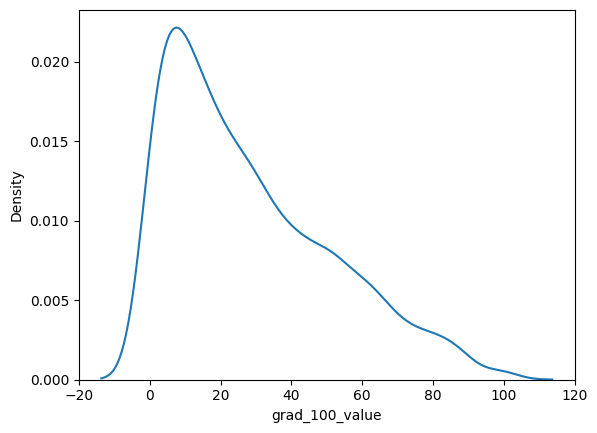

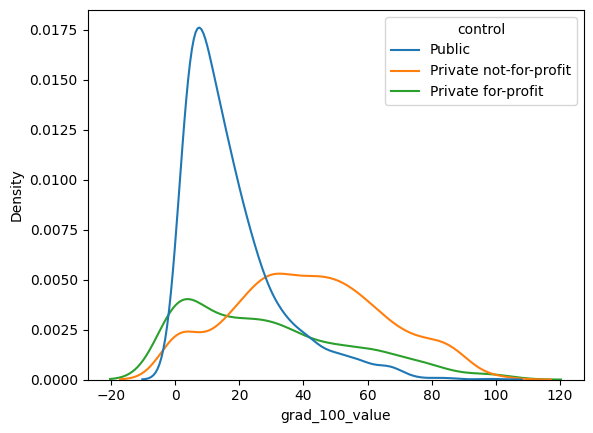

In [114]:
#4. 
sns.kdeplot(data=df, x='grad_100_value')
plt.show()
sns.kdeplot(data=df, x='grad_100_value', hue='control')
plt.show()

In [115]:
for name, group in df.groupby('control'):
    print(name, group['grad_100_value'].describe())

Private for-profit count    779.000000
mean      29.108858
std       25.601687
min        0.000000
25%        6.950000
50%       24.700000
75%       46.750000
max      100.000000
Name: grad_100_value, dtype: float64
Private not-for-profit count    1189.000000
mean       41.660976
std        23.551231
min         0.000000
25%        25.000000
50%        41.000000
75%        58.300000
max       100.000000
Name: grad_100_value, dtype: float64
Public count    1499.000000
mean       17.430887
std        14.729443
min         0.000000
25%         6.900000
50%        13.200000
75%        23.250000
max        97.800000
Name: grad_100_value, dtype: float64


Private not-for-profit instritutions appear to have to most favorable graduation rates. 

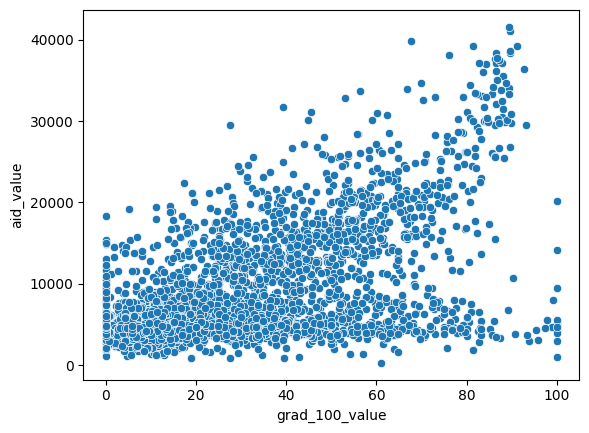

Correlation: 0.5758792845936075
Covariance: 88610.48316902434


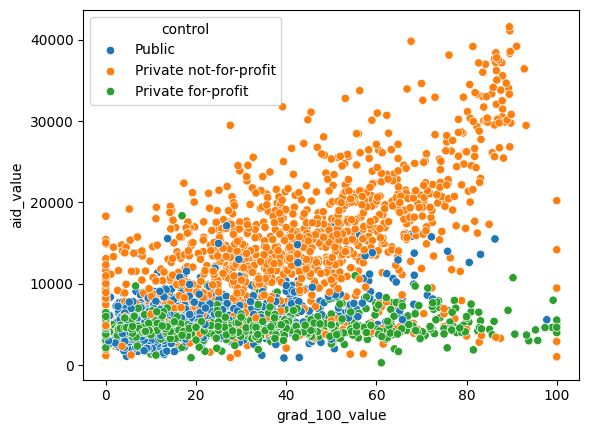

In [116]:
#5. 
sns.scatterplot(df, x='grad_100_value', y='aid_value')
plt.show()

print(f"Correlation: {df['grad_100_value'].corr(df['aid_value'])}")
print(f"Covariance: {df['grad_100_value'].cov(df['aid_value'])}")

sns.scatterplot(df, x='grad_100_value', y='aid_value', hue='control')
plt.show()

After conditioning on control, it can be seen that aid seeems to vary positively with graduation rates for private not-for-profit institutions, while for the public schools it varies less positively and private for-profit institutions it does not seem to vary at all. Private not-for-profit institutions also tend to give out much more aid than other institutions. 

Q6. Photo in GitHub repo

Q7.

In [117]:
#1. 
df = pd.read_csv("/workspace/scratchpad/data/ames_prices.csv")
df.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


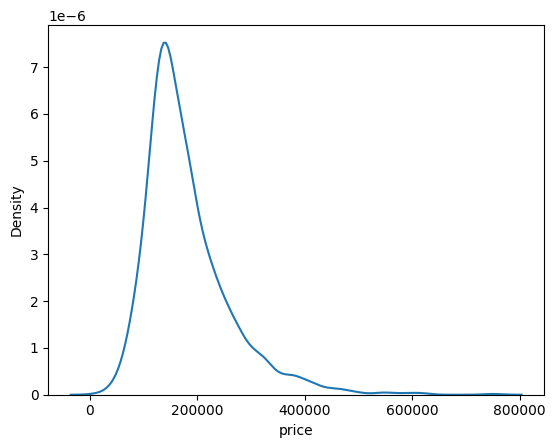

Describe table:
 count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64


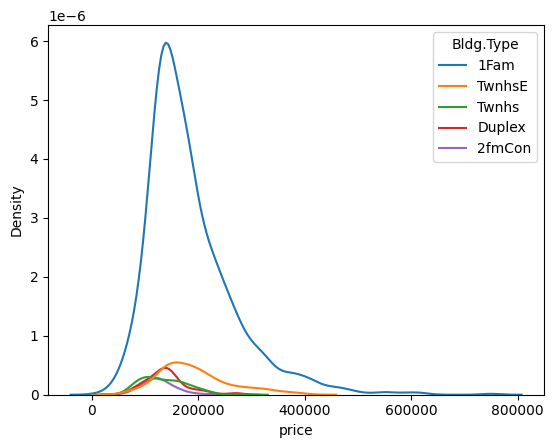

Describe tables grouped by building type:
             count           mean           std      min       25%       50%  \
Bldg.Type                                                                     
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   

                75%       max  
Bldg.Type                      
1Fam       220000.0  755000.0  
2fmCon     140000.0  228950.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
TwnhsE     222000.0  392500.0  


In [118]:
#2.
sns.kdeplot(x=df['price'])
plt.show()
print("Describe table:\n", df['price'].describe())

sns.kdeplot(x=df['price'], hue=df['Bldg.Type'])
plt.show()
print("Describe tables grouped by building type:\n", df['price'].groupby(df['Bldg.Type']).describe())

On average, an end-of-unit townhome is the most expensive, followed by a single family home. Single family homes have the highest variance in the transaction prices according to standard devation, also with end-of-unit townhomes. 

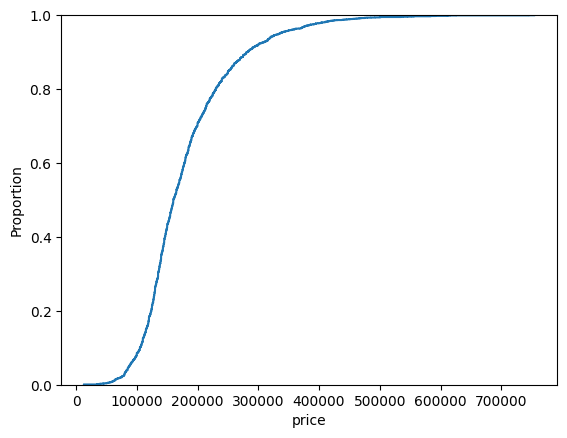

Minimum: 12789
.25 quantile: 129500.0
Median: 160000.0
.75 quantile: 213500.0
Maximum: 755000


In [119]:
#3. 
x = sns.ecdfplot(x=df['price'])
plt.show()

print(f"Minimum: {df['price'].min()}")
print(f".25 quantile: {np.quantile(df['price'],.25)}")
print(f"Median: {np.quantile(df['price'],.5)}")
print(f".75 quantile: {np.quantile(df['price'],.75)}")
print(f"Maximum: {df['price'].max()}")

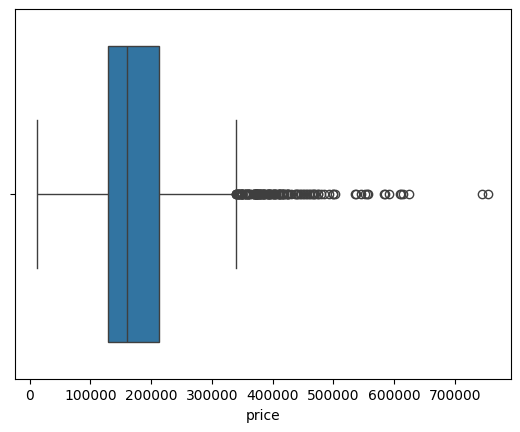

In [120]:
#4.
sns.boxplot(x=df['price'])
plt.show()


Yes, there are many upper outliers for price. 

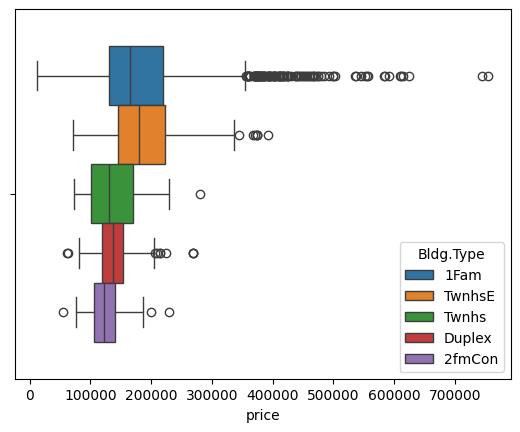

In [121]:
sns.boxplot(x=df['price'], hue =df['Bldg.Type'])
plt.show()

Single family homes have the most outlier, by far, and have the most spread. Only duplex and two-family conversions have lower outliers. 

In [122]:
#5. 

def outlier(x):
    q25 = np.quantile(df['price'], .25)
    q75 = np.quantile(df['price'], .75)
    iqr = q75 - q25
    uw = q75 + 1.5 * iqr # upper whisker
    lw = q25 - 1.5 * iqr # lower whisker
    upper_outlier = ( x > uw ).astype(int)
    lower_outlier = ( x < lw ).astype(int)
    outlier = upper_outlier + lower_outlier
    return outlier

df['outlier'] = outlier(df['price'])
df.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition,outlier
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,0
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,0
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,0
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,0
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,0


<Axes: xlabel='winsorized_price', ylabel='Density'>

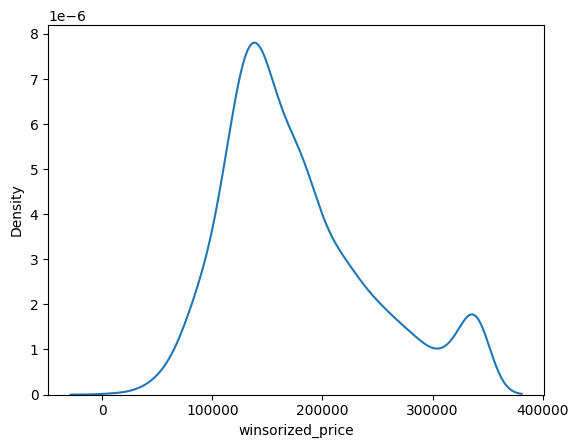

In [123]:
#6

x = df['price']

def outlier_analyze(x):
    q25 = np.quantile(df['price'], .25)
    q75 = np.quantile(df['price'], .75)
    iqr = q75 - q25
    uw = q75 + 1.5 * iqr # upper whisker
    lw = q25 - 1.5 * iqr # lower whisker
    upper_outlier = ( x > uw ).astype(int)
    lower_outlier = ( x < lw ).astype(int)
    outlier = upper_outlier + lower_outlier
    winsorize = (
            upper_outlier * uw + # map upper outlier to upper whisker
            lower_outlier * lw + # map lower outliers to lower whisker
            ( 1 - outlier ) * x # if neither, keep original value
        )

    return winsorize

df['winsorized_price'] = outlier_analyze(x)    

sns.kdeplot(x=df['winsorized_price'])

The spread of results of the windsorized price is much smaller, and the data is much less skewed, making it easier to see the shape of the distribution. 